# ML Preparation & Pipelines
This notebook contains functions for data preparation (standardizing, filtering, splitting), Scikit-learn pipelines for modeling, and model evaluation.

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Helper Functions

In [10]:
def standardize_column_names(df):
    """
    Standardizes column names in the dataframe:
    - Converts to lowercase
    - Replaces spaces with underscores
    """
    df = df.copy()
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    return df

def filter_data(df, column, value):
    """
    Filters data by a column and value.
    """
    if column in df.columns:
        return df[df[column] == value]
    return df

def split_features_target(df, target_column):
    """
    Takes a column name and splits X and y, based on target name.
    """
    if target_column not in df.columns:
        raise ValueError(f"Target column '{target_column}' not found in dataframe.")
    
    X = df.drop(columns=[target_column])
    y = df[target_column]
    return X, y

def split_train_test_data(X, y, test_size=0.2, random_state=42):
    """
    Splits Train and Test data.
    """
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

# 2. Evaluation Functions

In [11]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """
    Creates and plots a confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    return cm

def generate_classification_report(y_true, y_pred):
    """
    Prints a classification report.
    """
    report = classification_report(y_true, y_pred)
    print("Classification Report:")
    print(report)
    return report

def plot_roc_auc_curve(y_true, y_prob, title='ROC Curve'):
    """
    Constructs and plots an ROC (Receiver Operating Characteristic) curve and calculates AUC.
    Note: y_prob should be the probabilities of the positive class.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()
    return roc_auc

# 3. Load and Prepare Data

In [12]:
data_path = '../../data/cleaned/cleaned_call_data.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Data loaded.")
else:
    print("Data file not found. Please ensure setup_data.py has been run.")
    # Creating dummy data for demonstration if file missing (or stop)
    df = pd.DataFrame()

if not df.empty:
    # a. Standardize column names
    df = standardize_column_names(df)
    
    # b. Filter data example (commented out to keep full data for modeling)
    # df_filtered = filter_data(df, 'disposition', 'ANSWERED')
    
    # Prepare for Modeling
    # Assuming 'billable_status' is the target. It might be boolean or string.
    # Let's clean it up for classification
    target = 'billable_status'
    
    # Drop non-predictive columns like IDs if they exist
    if 'call_id' in df.columns:
        df = df.drop(columns=['call_id'])
        
    # Convert boolean target to int if necessary
    if df[target].dtype == bool:
        df[target] = df[target].astype(int)
        
    # c. Split X and y
    X, y = split_features_target(df, target)
    
    # d. Split Train and Test
    X_train, X_test, y_train, y_test = split_train_test_data(X, y)
    
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Data loaded.
Train shape: (4, 4), Test shape: (2, 4)


# 4. Sklearn Pipeline 1: Random Forest + Feature Importance & Evaluation

Numeric features: ['call_duration', 'zip_code']
Categorical features: ['call_start_time', 'disposition']
Random Forest Pipeline fitted.

Feature Importance:
                               feature  importance
1                             zip_code    0.286275
0                        call_duration    0.266667
6                 disposition_Answered    0.116340
5  call_start_time_2025-01-20 09:15:30    0.105882
8                  disposition_Dropped    0.086275
7                     disposition_Busy    0.062745
3  call_start_time_2025-01-20 08:55:00    0.047059
2  call_start_time_2025-01-20 08:45:22    0.024837
4  call_start_time_2025-01-20 09:10:00    0.003922

--- Model Evaluation (Test Set) ---


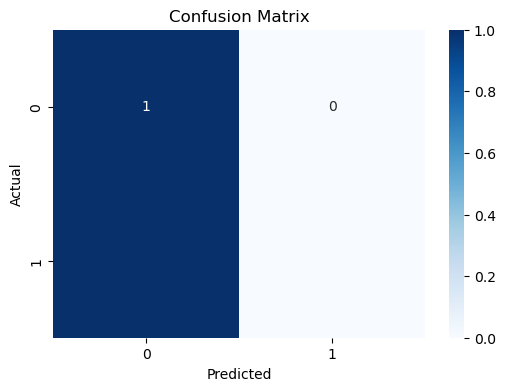

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


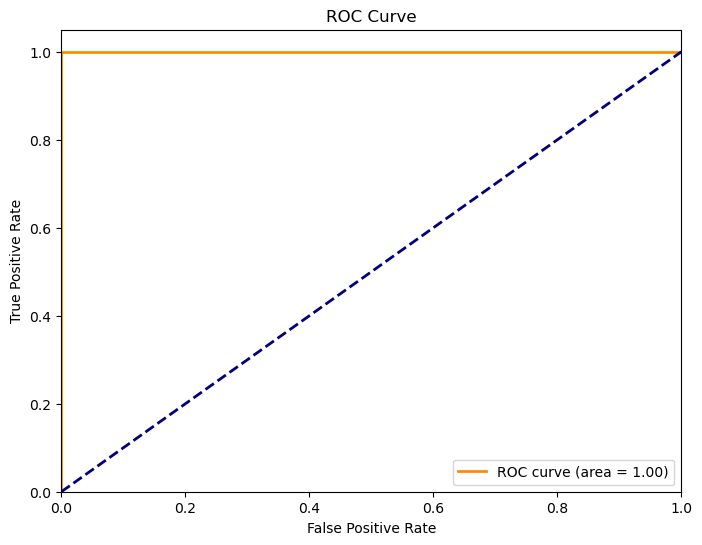

In [13]:
if not df.empty:
    # Identify column types
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"Numeric features: {numeric_features}")
    print(f"Categorical features: {categorical_features}")

    # a. Scale numeric columns
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    # b. Encode Categorical Values using one-hot encoding
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # d. combine a and b into Combine preprocessing steps using ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    # e. create the final step random forest
    pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

    # Fit the pipeline
    pipeline_rf.fit(X_train, y_train)
    print("Random Forest Pipeline fitted.")

    # f. print out the feature importance
    rf_model = pipeline_rf.named_steps['classifier']
    
    # Get feature names from preprocessor
    feature_names = []
    feature_names.extend(numeric_features)
    
    if categorical_features:
        cat_encoder = pipeline_rf.named_steps['preprocessor'].named_transformers_['cat']['onehot']
        cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
        feature_names.extend(cat_feature_names)
        
    importances = rf_model.feature_importances_
    
    # Create a DataFrame for visualization
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
    
    print("\nFeature Importance:")
    print(feature_importance_df)
    
    # --- Model Evaluation ---
    print("\n--- Model Evaluation (Test Set) ---")
    
    # Predictions
    y_pred = pipeline_rf.predict(X_test)
    y_prob = pipeline_rf.predict_proba(X_test)[:, 1] # Probability of positive class
    
    # 1. Confusion Matrix
    plot_confusion_matrix(y_test, y_pred)
    
    # 2. Classification Report
    generate_classification_report(y_test, y_pred)
    
    # 3. ROC/AUC Curve
    # Only valid if there are both classes in y_test
    if len(np.unique(y_test)) > 1:
        plot_roc_auc_curve(y_test, y_prob)
    else:
        print("\nSkipping ROC Curve: Test set contains only one class.")

# 5. Sklearn Pipeline 2: Preprocessing + Commented Models

In [14]:
if not df.empty:
    # a. Scale numeric columns
    # b. Encode Categorical Values using one-hot encoding
    # c. combine a and b into Combine preprocessing steps using ColumnTransformer
    # (Reusing preprocessor defined above as it matches requirements)
    
    pipeline_2 = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', RandomForestClassifier())]) # Placeholder estimator
    
    # d. Add commented lines for Sklearn for linearregresson, logrithmic regression, xgboost, linearregression LASSO
    
    # from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
    # import xgboost as xgb
    
    # --- Linear Regression ---
    # pipeline_linear = Pipeline(steps=[('preprocessor', preprocessor),
    #                                   ('regressor', LinearRegression())])
    
    # --- Logistic Regression ---
    # pipeline_logistic = Pipeline(steps=[('preprocessor', preprocessor),
    #                                     ('classifier', LogisticRegression())])
    
    # --- XGBoost ---
    # pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor),
    #                                ('classifier', xgb.XGBClassifier())]) # or XGBRegressor
    
    # --- LASSO Regression ---
    # pipeline_lasso = Pipeline(steps=[('preprocessor', preprocessor),
    #                                  ('regressor', Lasso(alpha=0.1))])
    
    print("Pipeline 2 structure created with commented alternative models.")

Pipeline 2 structure created with commented alternative models.
